Generating TPC-H (SF=0.5)...
TPC-H ready.

EXPERIMENT 3: Cache Efficiency

[3.1] Sequential Scan
Time: 0.0043s | Throughput: 10672.92 MB/s

[3.2] Random Access
Time: 0.0870s | Throughput: 574.45 MB/s

[3.3] Hash Aggregation
Time: 0.4541s | Throughput: 151.19 MB/s


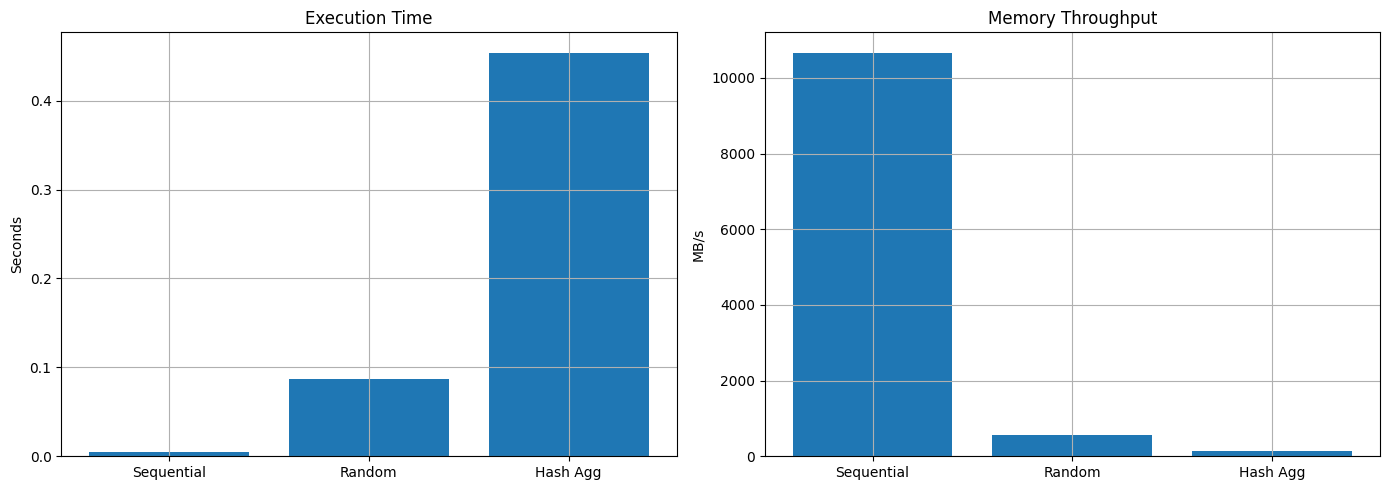

,access_pattern,execution_time,throughput_mb_s
0,Sequential,0.004289,10672.919063
1,Random,0.087040,574.449519
2,Hash Agg,0.454118,151.187456


In [ ]:
"""
Experiment 3: Cache Efficiency (Improved, Scalable)
TPC-H Dataset
"""

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time


# -----------------------------
# 1. Init TPC-H
# -----------------------------
def init_tpch(scale_factor=0.5):   # increase for larger data
    con = duckdb.connect(':memory:')
    
    print(f"Generating TPC-H (SF={scale_factor})...")
    con.execute("INSTALL tpch")
    con.execute("LOAD tpch")
    con.execute(f"CALL dbgen(sf={scale_factor})")
    
    print("TPC-H ready.\n")
    return con


# -----------------------------
# 2. Timing (robust)
# -----------------------------
def benchmark_query(con, query, repeat=2):

    # warm-up
    con.execute(query).fetchall()

    times = []
    for _ in range(repeat):
        start = time.perf_counter()
        con.execute(query).fetchall()
        times.append(time.perf_counter() - start)

    return np.mean(times)


# -----------------------------
# 3. Experiment 3
# -----------------------------
def experiment_3(con):

    print("="*80)
    print("EXPERIMENT 3: Cache Efficiency")
    print("="*80)

    results = {
        "access_pattern": [],
        "execution_time": [],
        "throughput_mb_s": []
    }

    row_count = con.execute("SELECT COUNT(*) FROM lineitem").fetchone()[0]

    # -------------------------
    # 3.1 Sequential (best case)
    # -------------------------
    print("\n[3.1] Sequential Scan")

    query_seq = """
        SELECT SUM(l_quantity), AVG(l_extendedprice)
        FROM lineitem
    """

    t_seq = benchmark_query(con, query_seq)

    data_mb = (row_count * 16) / (1024 * 1024)  # 2 columns × 8 bytes
    throughput_seq = data_mb / t_seq

    results["access_pattern"].append("Sequential")
    results["execution_time"].append(t_seq)
    results["throughput_mb_s"].append(throughput_seq)

    print(f"Time: {t_seq:.4f}s | Throughput: {throughput_seq:.2f} MB/s")


    # -------------------------
    # 3.2 Random access (join)
    # -------------------------
    print("\n[3.2] Random Access")

    query_rand = """
        SELECT o.o_orderkey, l.l_quantity
        FROM orders o
        JOIN lineitem l ON o.o_orderkey = l.l_orderkey
        WHERE o.o_orderkey IN (
            SELECT o_orderkey
            FROM orders
            WHERE random() < 0.01
            LIMIT 10000
        )
    """

    t_rand = benchmark_query(con, query_rand)

    data_mb = 50  # approximate working set
    throughput_rand = data_mb / t_rand

    results["access_pattern"].append("Random")
    results["execution_time"].append(t_rand)
    results["throughput_mb_s"].append(throughput_rand)

    print(f"Time: {t_rand:.4f}s | Throughput: {throughput_rand:.2f} MB/s")


    # -------------------------
    # 3.3 Hash aggregation
    # -------------------------
    print("\n[3.3] Hash Aggregation")

    query_agg = """
        SELECT 
            l_partkey,
            COUNT(*),
            SUM(l_quantity),
            AVG(l_extendedprice)
        FROM lineitem
        GROUP BY l_partkey
    """

    t_agg = benchmark_query(con, query_agg)

    data_mb = (row_count * 24) / (1024 * 1024)
    throughput_agg = data_mb / t_agg

    results["access_pattern"].append("Hash Agg")
    results["execution_time"].append(t_agg)
    results["throughput_mb_s"].append(throughput_agg)

    print(f"Time: {t_agg:.4f}s | Throughput: {throughput_agg:.2f} MB/s")

    return results


# -----------------------------
# 4. Plot (Notebook)
# -----------------------------
def plot_experiment_3(results):

    df = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Execution time
    axes[0].bar(df["access_pattern"], df["execution_time"])
    axes[0].set_title("Execution Time")
    axes[0].set_ylabel("Seconds")
    axes[0].grid()

    # Throughput
    axes[1].bar(df["access_pattern"], df["throughput_mb_s"])
    axes[1].set_title("Memory Throughput")
    axes[1].set_ylabel("MB/s")
    axes[1].grid()

    plt.tight_layout()
    plt.show()


# -----------------------------
# 5. RUN
# -----------------------------
con = init_tpch(scale_factor=0.5)   # try 1.0 if RAM allows

results = experiment_3(con)

plot_experiment_3(results)

pd.DataFrame(results)